# Exploratory Data Analysis (EDA): Higgs Boson Collision Data

## 1. Project Context and Setup
In this notebook, we perform the initial data exploration on the CERN ATLAS simulated dataset. The goal is to classify collision events as either a rare Higgs boson decay (`Signal`) or standard collision noise (`Background`). 

First, we import the core data manipulation and visualization libraries required for this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # Keeps the output clean
sns.set_theme(style="whitegrid")
print("Dependencies loaded.")

Dependencies loaded.


## 2. Data Loading & Handling Physics Anomalies
The dataset contains 30 kinematic features. A critical physics-specific detail in this dataset is the presence of missing values encoded as `$-999.0$`. 

In detector physics, if a specific particle (like a jet) is not produced in a collision, any derived kinematic variables relying on that particle cannot be calculated. Leaving these values as `$-999.0$` would severely skew the mathematical calculations of our machine learning models. We must replace them with standard `NaN` values before proceeding.

In [2]:
print("Loading data...")
# Load the dataset
df = pd.read_csv('training.csv')

print(f"Original dataset shape: {df.shape}")

# Replace the physics anomaly (-999.0) with standard NaN
df.replace(-999.0, np.nan, inplace=True)
print("Anomalies replaced with NaN.")

Loading data...
Original dataset shape: (250000, 33)
Anomalies replaced with NaN.


## 3. Class Imbalance and Missing Data Assessment
Before training any models, we need to understand two things:
1. **Target Imbalance:** Rare particle decays are exactly that—rare. We need to quantify the ratio of Signal to Background events.
2. **Missing Feature Density:** We need to evaluate which derived features (`DER_`) suffer the most from the `NaN` replacements to determine our imputation strategy later.

In [3]:
print("\n--- Signal vs Background Distribution ---")
print(df['Label'].value_counts(normalize=True) * 100)

print("\n--- Missing Values Percentage (>0%) ---")
missing = df.isna().mean() * 100
missing_features = missing[missing > 0].sort_values(ascending=False)
print(missing_features)


--- Signal vs Background Distribution ---
Label
b    65.7332
s    34.2668
Name: proportion, dtype: float64

--- Missing Values Percentage (>0%) ---
DER_deltaeta_jet_jet      70.9828
DER_mass_jet_jet          70.9828
DER_prodeta_jet_jet       70.9828
PRI_jet_subleading_phi    70.9828
DER_lep_eta_centrality    70.9828
PRI_jet_subleading_eta    70.9828
PRI_jet_subleading_pt     70.9828
PRI_jet_leading_eta       39.9652
PRI_jet_leading_pt        39.9652
PRI_jet_leading_phi       39.9652
DER_mass_MMC              15.2456
dtype: float64


## 4. Visualizing the Physics
To prove that machine learning can separate this data, we visualize the `DER_mass_MMC` feature. This represents the estimated mass of the Higgs boson candidate. 

Because the Higgs boson has a specific physical mass (around 125 GeV), the `Signal` distribution should show a distinct peak or "bump" in that region, whereas the `Background` distribution will be much broader and exponentially decaying. We will also plot the percentage of missing data across the features.

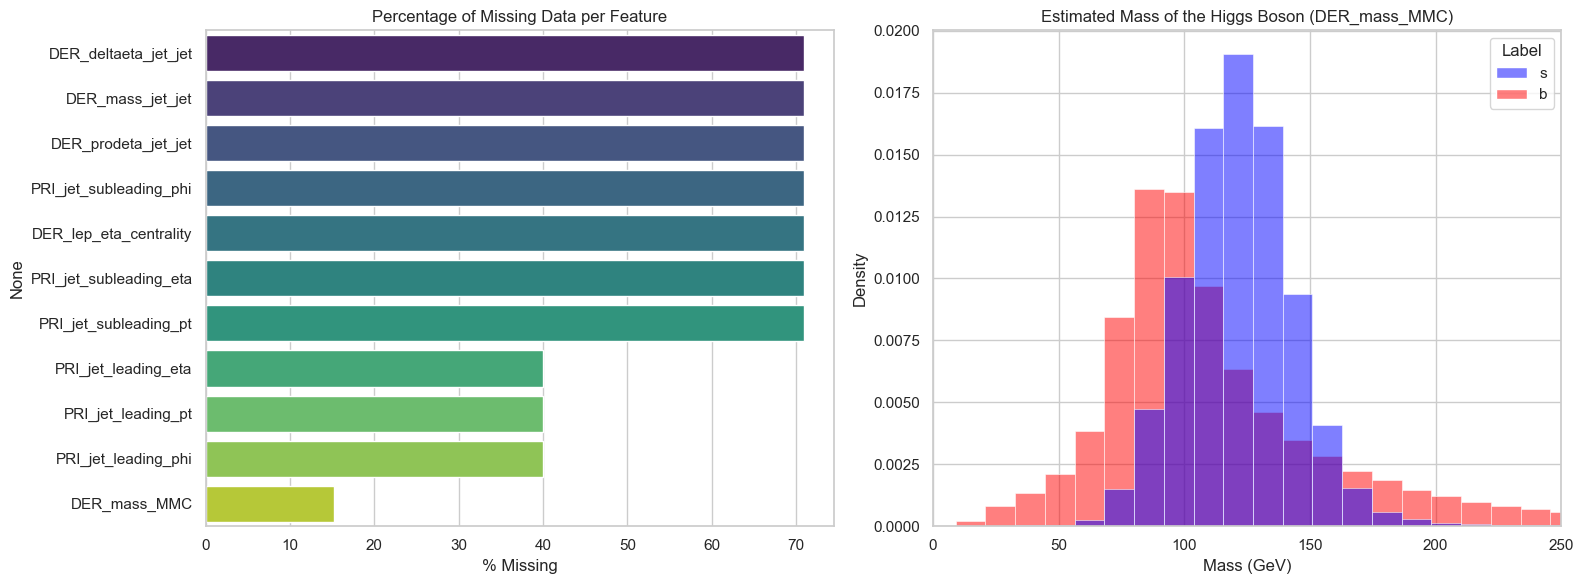

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Missing Data Bar Chart
sns.barplot(x=missing_features.values, y=missing_features.index, ax=axes[0], palette="viridis")
axes[0].set_title("Percentage of Missing Data per Feature")
axes[0].set_xlabel("% Missing")

# Plot 2: Physics (Higgs Mass Distribution)
sns.histplot(
    data=df, x='DER_mass_MMC', hue='Label', bins=100, 
    stat='density', common_norm=False, palette={'s': 'blue', 'b': 'red'}, 
    alpha=0.5, ax=axes[1]
)
axes[1].set_title('Estimated Mass of the Higgs Boson (DER_mass_MMC)')
axes[1].set_xlabel('Mass (GeV)')
axes[1].set_xlim(0, 250)

plt.tight_layout()
plt.show()